In [1]:
import glob, os
import numpy as np
import pandas as pd
import matplotlib as mpl
from pathlib import Path
import astropy.units as u
from astropy.table import Table
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from astropy.coordinates import SkyCoord
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec

from myutils import all_utils as au



# LSST 1-year simulation
20 x 1 year with detection in Rubin using 250 /yr/GPc³ rate

In [2]:
# Path plots
path_plots = "paper_plots/ocean_oneyear/"
os.mkdir(path_plots) if not os.path.exists(path_plots) else None


In [3]:

df_header_list=[]
df_phot_list=[]
list_to_read = glob.glob("data/SIMS_KN_OCEAN_ONEYEAR_250_YDET/*/*PHOT.FITS.gz")
print(f"Found {len(list_to_read)} PHOT.FITS.gz files to read.")
list_n_KN = []
for fphot in list_to_read:
    df_header_tmp, df_phot_tmp = au.read_fits(fphot, drop_separators=True)
    print(f"Reading {fphot} with length {len(df_phot_tmp)}")
    df_header_list.append(df_header_tmp)
    df_phot_list.append(df_phot_tmp)
    list_n_KN.append(df_header_tmp['SNID'].nunique())
df_header = pd.concat(df_header_list, ignore_index=True)
# Read all PHOT.FITS.gz files and concatenate them    
df_phot = pd.concat(df_phot_list, ignore_index=True)
print(f"Number of light curves: {len(df_header)}")
print(f"Number of photometric points: {df_phot.groupby('SNID').count()['MJD'].median()} +- {df_phot.groupby('SNID').count()['MJD'].std()}")

Found 40 PHOT.FITS.gz files to read.
Reading data/SIMS_KN_OCEAN_ONEYEAR_250_YDET/PIP_AMR_KN_OCEAN_ONEYEARONLY_LSST_KN_KASEN_NOHOST/PIP_AMR_KN_OCEAN_ONEYEARO43549_NONIaMODEL00-0002_PHOT.FITS.gz with length 812
Reading data/SIMS_KN_OCEAN_ONEYEAR_250_YDET/PIP_AMR_KN_OCEAN_ONEYEARONLY_LSST_KN_KASEN_NOHOST/PIP_AMR_KN_OCEAN_ONEYEARO43549_NONIaMODEL00-0005_PHOT.FITS.gz with length 729
Reading data/SIMS_KN_OCEAN_ONEYEAR_250_YDET/PIP_AMR_KN_OCEAN_ONEYEARONLY_LSST_KN_KASEN_NOHOST/PIP_AMR_KN_OCEAN_ONEYEARO43549_NONIaMODEL00-0010_PHOT.FITS.gz with length 950
Reading data/SIMS_KN_OCEAN_ONEYEAR_250_YDET/PIP_AMR_KN_OCEAN_ONEYEARONLY_LSST_KN_KASEN_NOHOST/PIP_AMR_KN_OCEAN_ONEYEARO43549_NONIaMODEL00-0017_PHOT.FITS.gz with length 1049
Reading data/SIMS_KN_OCEAN_ONEYEAR_250_YDET/PIP_AMR_KN_OCEAN_ONEYEARONLY_LSST_KN_KASEN_NOHOST/PIP_AMR_KN_OCEAN_ONEYEARO43549_NONIaMODEL00-0020_PHOT.FITS.gz with length 853
Reading data/SIMS_KN_OCEAN_ONEYEAR_250_YDET/PIP_AMR_KN_OCEAN_ONEYEARONLY_LSST_KN_KASEN_NOHOST/PIP_AMR_

This means that we get per year (20 realisations)

### Two ways of getting estimation of KN per year

In [4]:
# 1 direct analysis
tmp = df_header.groupby('model_name').count()['SNID']
print(f"Number of KNe per year {np.round(tmp.mean()/20,1)} pm {np.round(tmp.std(),1)}")


Number of KNe per year 41.9 pm 10.6


In [5]:
mean_kn = np.mean(list_n_KN)
std_kn = np.std(list_n_KN)
print(f"Mean: {mean_kn:.1f}, Std: {std_kn:.1f}")

Mean: 41.9, Std: 3.6


In [6]:
#How many should we expect?

import math

def calculate_survey_events(rate = 320e-9,fraction_sky = 0.5, depth = 400,survey_time=1):
    """
    Calculate expected number of events for southern sky survey
    """
    # Given parameters
    # rate events per year per Mpc³
    # depth = 400 Mpc
    # survey_time = 1  # year
    
    print(f"Rate: {rate} events/yr/Mpc³ | Survey depth: {depth} Mpc | Survey time: {survey_time} year")
    
    # Calculate volume of southern hemisphere out to 400 Mpc
    # Volume of sphere = (4/3) * π * r³
    # Volume of hemisphere = (1/2) * (4/3) * π * r³ = (2/3) * π * r³
    
    radius = depth
    hemisphere_volume = fraction_sky * (4/3) * math.pi * (radius ** 3)
    
    # Calculate expected number of events
    expected_events = rate * hemisphere_volume * survey_time
    
    if expected_events < 1:
        print(f"With {expected_events:.2f} expected events, detection is unlikely in 1 year")
    else:
        print(f"You'd expect about {round(expected_events)} events in 1 year")
    
    return expected_events, hemisphere_volume

print('Southern hemisphere')
events, volume = calculate_survey_events(rate = 320e-9,fraction_sky = 0.5, depth = 400,survey_time=1)

print('1/3 of Southern hemisphere')
events, volume = calculate_survey_events(rate = 320e-9,fraction_sky = 0.5*0.3, depth = 400,survey_time=1)



Southern hemisphere
Rate: 3.2e-07 events/yr/Mpc³ | Survey depth: 400 Mpc | Survey time: 1 year
You'd expect about 43 events in 1 year
1/3 of Southern hemisphere
Rate: 3.2e-07 events/yr/Mpc³ | Survey depth: 400 Mpc | Survey time: 1 year
You'd expect about 13 events in 1 year


Kasen: 831 light curves
Bulla: 846 light curves


Text(0, 0.5, 'Number of light curves')

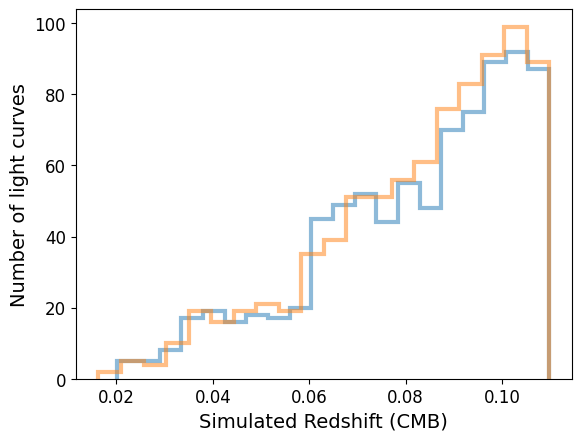

In [7]:
for mod in df_header['model_name'].unique():
    print(f"{mod}: {len(df_header[df_header['model_name']==mod])} light curves")
    plt.hist(df_header[df_header['model_name']==mod]['SIM_REDSHIFT_CMB'], bins=20, alpha=0.5, label=mod, histtype='step', density=False)
plt.xlabel('Simulated Redshift (CMB)')
plt.ylabel('Number of light curves')

In [8]:
df_header.keys().to_list()

['SNID',
 'FAKE',
 'RA',
 'DEC',
 'PIXSIZE',
 'NXPIX',
 'NYPIX',
 'SNTYPE',
 'NOBS',
 'PTROBS_MIN',
 'PTROBS_MAX',
 'MWEBV',
 'MWEBV_ERR',
 'REDSHIFT_HELIO',
 'REDSHIFT_HELIO_ERR',
 'REDSHIFT_FINAL',
 'REDSHIFT_FINAL_ERR',
 'MASK_REDSHIFT_SOURCE',
 'VPEC',
 'VPEC_ERR',
 'LENSDMU',
 'LENSDMU_ERR',
 'HOSTGAL_NMATCH',
 'HOSTGAL_NMATCH2',
 'HOSTGAL_OBJID',
 'HOSTGAL_FLAG',
 'HOSTGAL_PHOTOZ',
 'HOSTGAL_PHOTOZ_ERR',
 'HOSTGAL_SPECZ',
 'HOSTGAL_SPECZ_ERR',
 'HOSTGAL_RA',
 'HOSTGAL_DEC',
 'HOSTGAL_SNSEP',
 'HOSTGAL_DDLR',
 'HOSTGAL_CONFUSION',
 'HOSTGAL_LOGMASS',
 'HOSTGAL_LOGMASS_ERR',
 'HOSTGAL_LOGSFR',
 'HOSTGAL_LOGSFR_ERR',
 'HOSTGAL_LOGsSFR',
 'HOSTGAL_LOGsSFR_ERR',
 'HOSTGAL_COLOR',
 'HOSTGAL_COLOR_ERR',
 'HOSTGAL_ELLIPTICITY',
 'HOSTGAL_OBJID2',
 'HOSTGAL_SQRADIUS',
 'HOSTGAL_OBJID_UNIQUE',
 'HOSTGAL_MAG_u',
 'HOSTGAL_MAG_g',
 'HOSTGAL_MAG_r',
 'HOSTGAL_MAG_i',
 'HOSTGAL_MAG_z',
 'HOSTGAL_MAG_Y',
 'HOSTGAL_MAGERR_u',
 'HOSTGAL_MAGERR_g',
 'HOSTGAL_MAGERR_r',
 'HOSTGAL_MAGERR_i',
 'HOSTG